In [1]:
import numpy as np
import pandas as pd
import spice_net as spn

# Generating data

y = (x * z)³

In [2]:
np.random.seed(42)
x_data = np.random.uniform(low=-1.0, high=1.0, size=(3000,))  # TODO: Back to 3000
#z_data = np.random.standard_normal(size=(3000,))
z_data = np.random.uniform(low=-1.0, high=1.0, size=(3000,))
#result_data = np.power(x_data * z_data, 3)
result_data = x_data * z_data

df = pd.DataFrame(np.array([x_data, z_data, result_data]).T, columns=['x_data', 'z_data', 'y_data'])
df

,x_data,z_data,y_data
0,-0.250920,0.345406,-0.086669
1,0.901429,0.593363,0.534874
2,0.463988,-0.499064,-0.231560
3,0.197317,0.249748,0.049280
4,-0.687963,0.143492,-0.098717
...,...,...,...
2995,0.730592,0.368871,0.269494
2996,-0.685454,0.006441,-0.004415
2997,-0.380424,0.530298,-0.201738
2998,-0.419909,-0.029419,0.012353


In [3]:


som_size = 50

som_1 = spn.SpiceNetSom(n_neurons=som_size,
                        key='x_data',
                        value_range_start=df['x_data'].min(),
                        value_range_end=df['x_data'].max(),
                        lrf_tuning_curve=spn.ConstLRF(0.8),
                        lrf_interaction_kernel=spn.ConstLRF(0.8))

som_2 = spn.SpiceNetSom(n_neurons=som_size,
                        key='z_data',
                        value_range_start=df['z_data'].min(),
                        value_range_end=df['z_data'].max(),
                        lrf_tuning_curve=spn.ConstLRF(0.8),
                        lrf_interaction_kernel=spn.ConstLRF(0.8))

som_3 = spn.SpiceNetSom(n_neurons=som_size,
                        key='y_data',
                        value_range_start=df['y_data'].min(),
                        value_range_end=df['y_data'].max(),
                        lrf_tuning_curve=spn.ConstLRF(0.8),
                        lrf_interaction_kernel=spn.ConstLRF(0.8))

correlation_matrix = spn.SpiceNetHcm([som_1, som_2, som_3], spn.ConstLRF(0.8), spn.ConstLRF(0.8))

spice_net = spn.SpiceNet(correlation_matrix)

In [4]:
input_data = df[['x_data', 'z_data']].apply(lambda row: row.to_numpy(), axis=1).tolist()
training_data = {
    'x_data': df['x_data'].tolist(),
    'z_data': df['z_data'].tolist(),
    'y_data': df['y_data'].tolist()
}
spice_net.fit(training_data, epochs_on_batch=10, batch_size=None, print_output=True)


100%|██████████| 1/1 [01:16<00:00, 76.97s/it]

Time spend on the Components: 
Som: 12.681458950042725 s | Convolution Matrix: 64.28546094894409 s


In [5]:
#np.save('gpt_imp', correlation_matrix.get_matrix())

In [10]:
#spn.plot_som(som_1, True)
spn.plot_som(som_2, True)
#spn.plot_hcm(correlation_matrix)
spn.plot_hcm(correlation_matrix, filter_start=190, height=900)

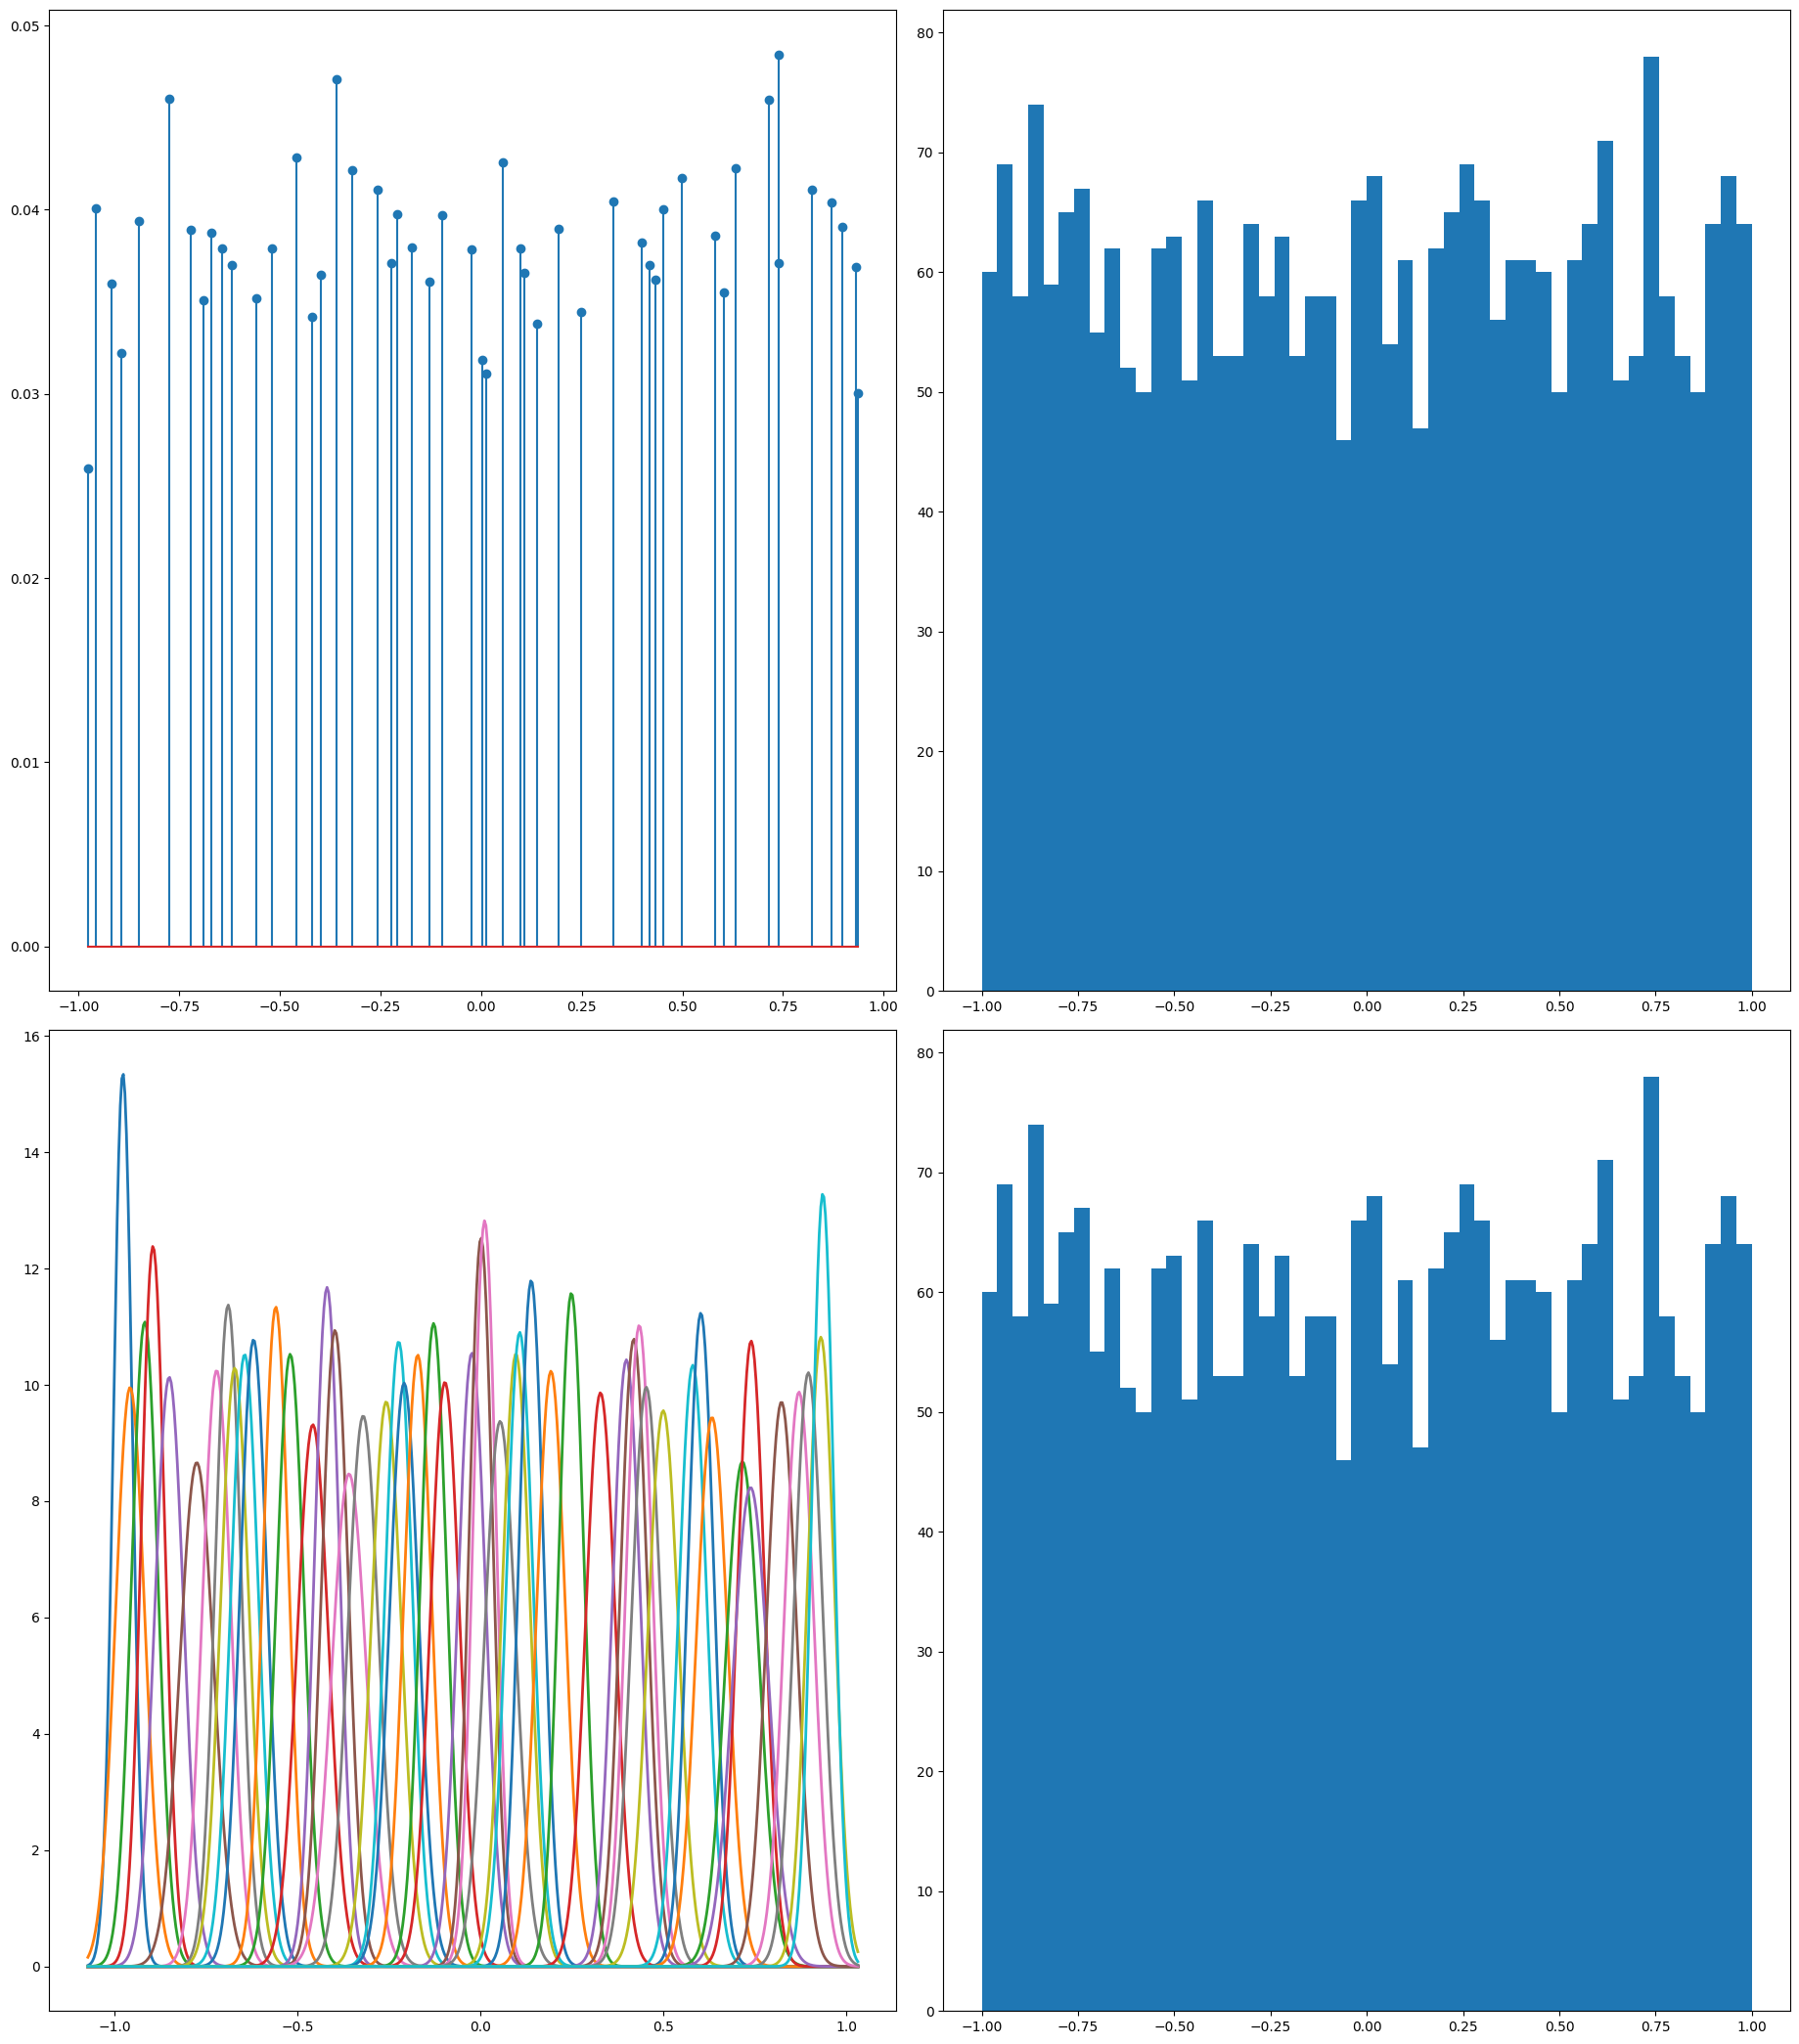

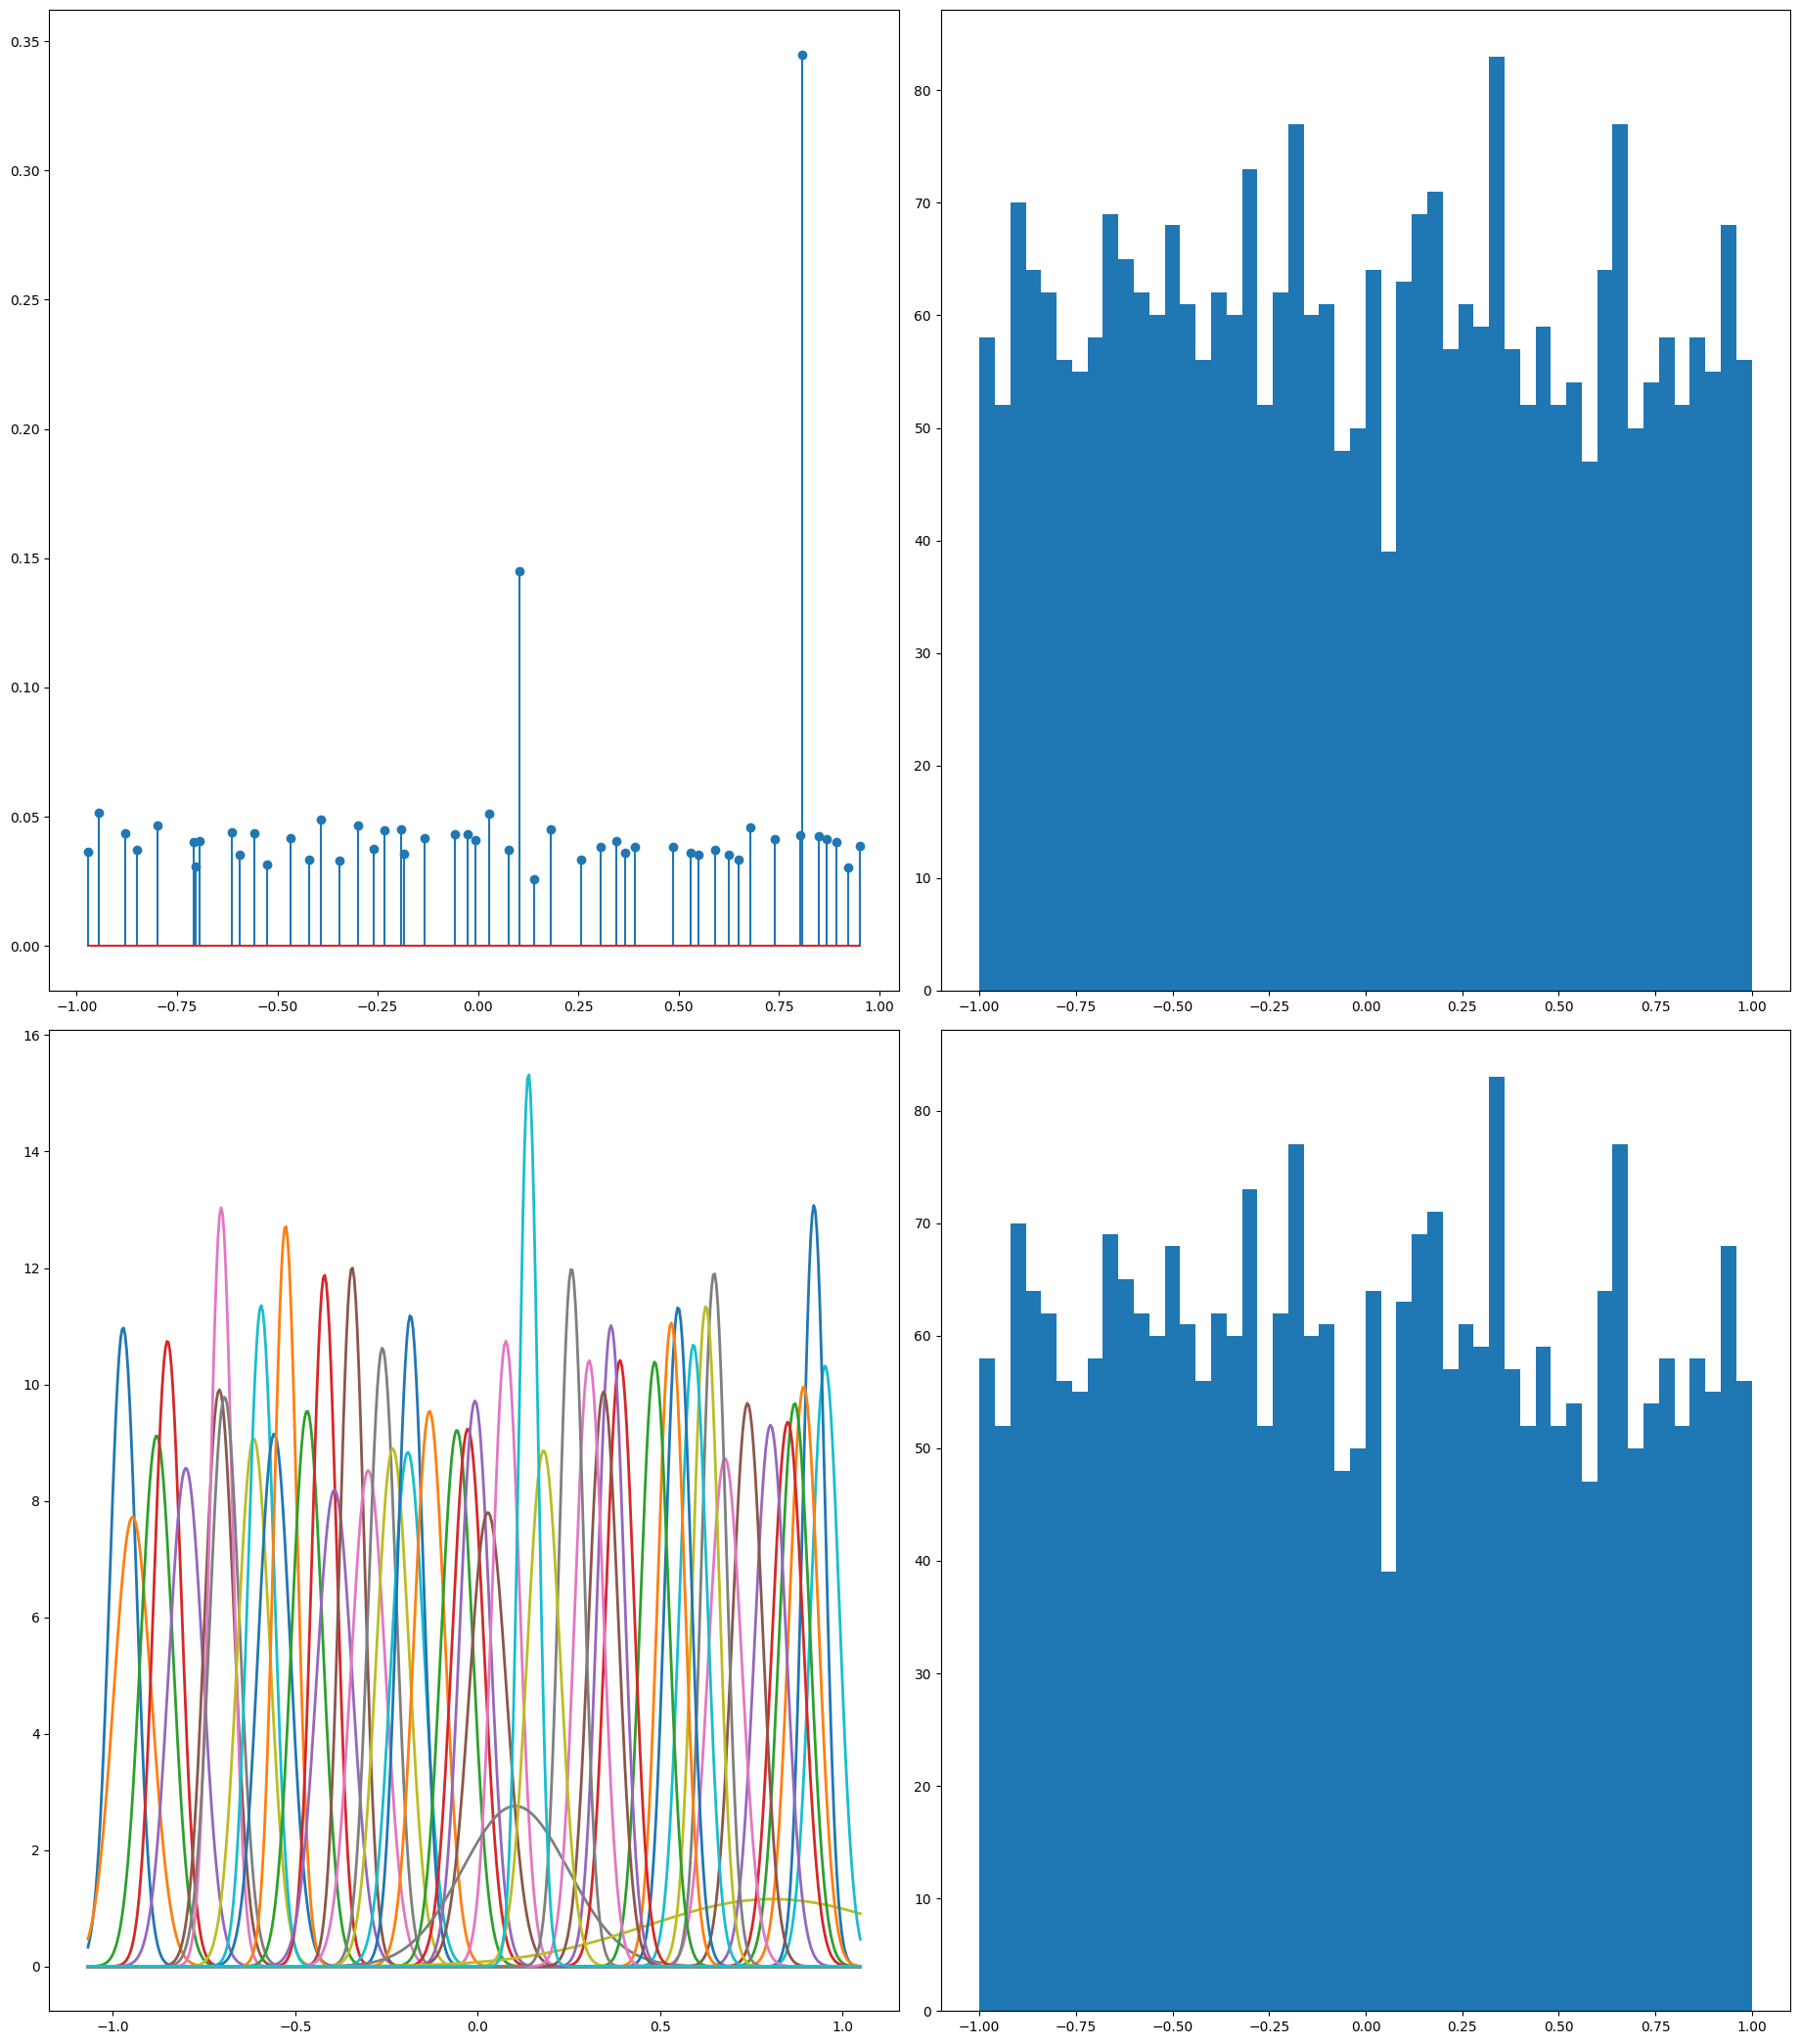

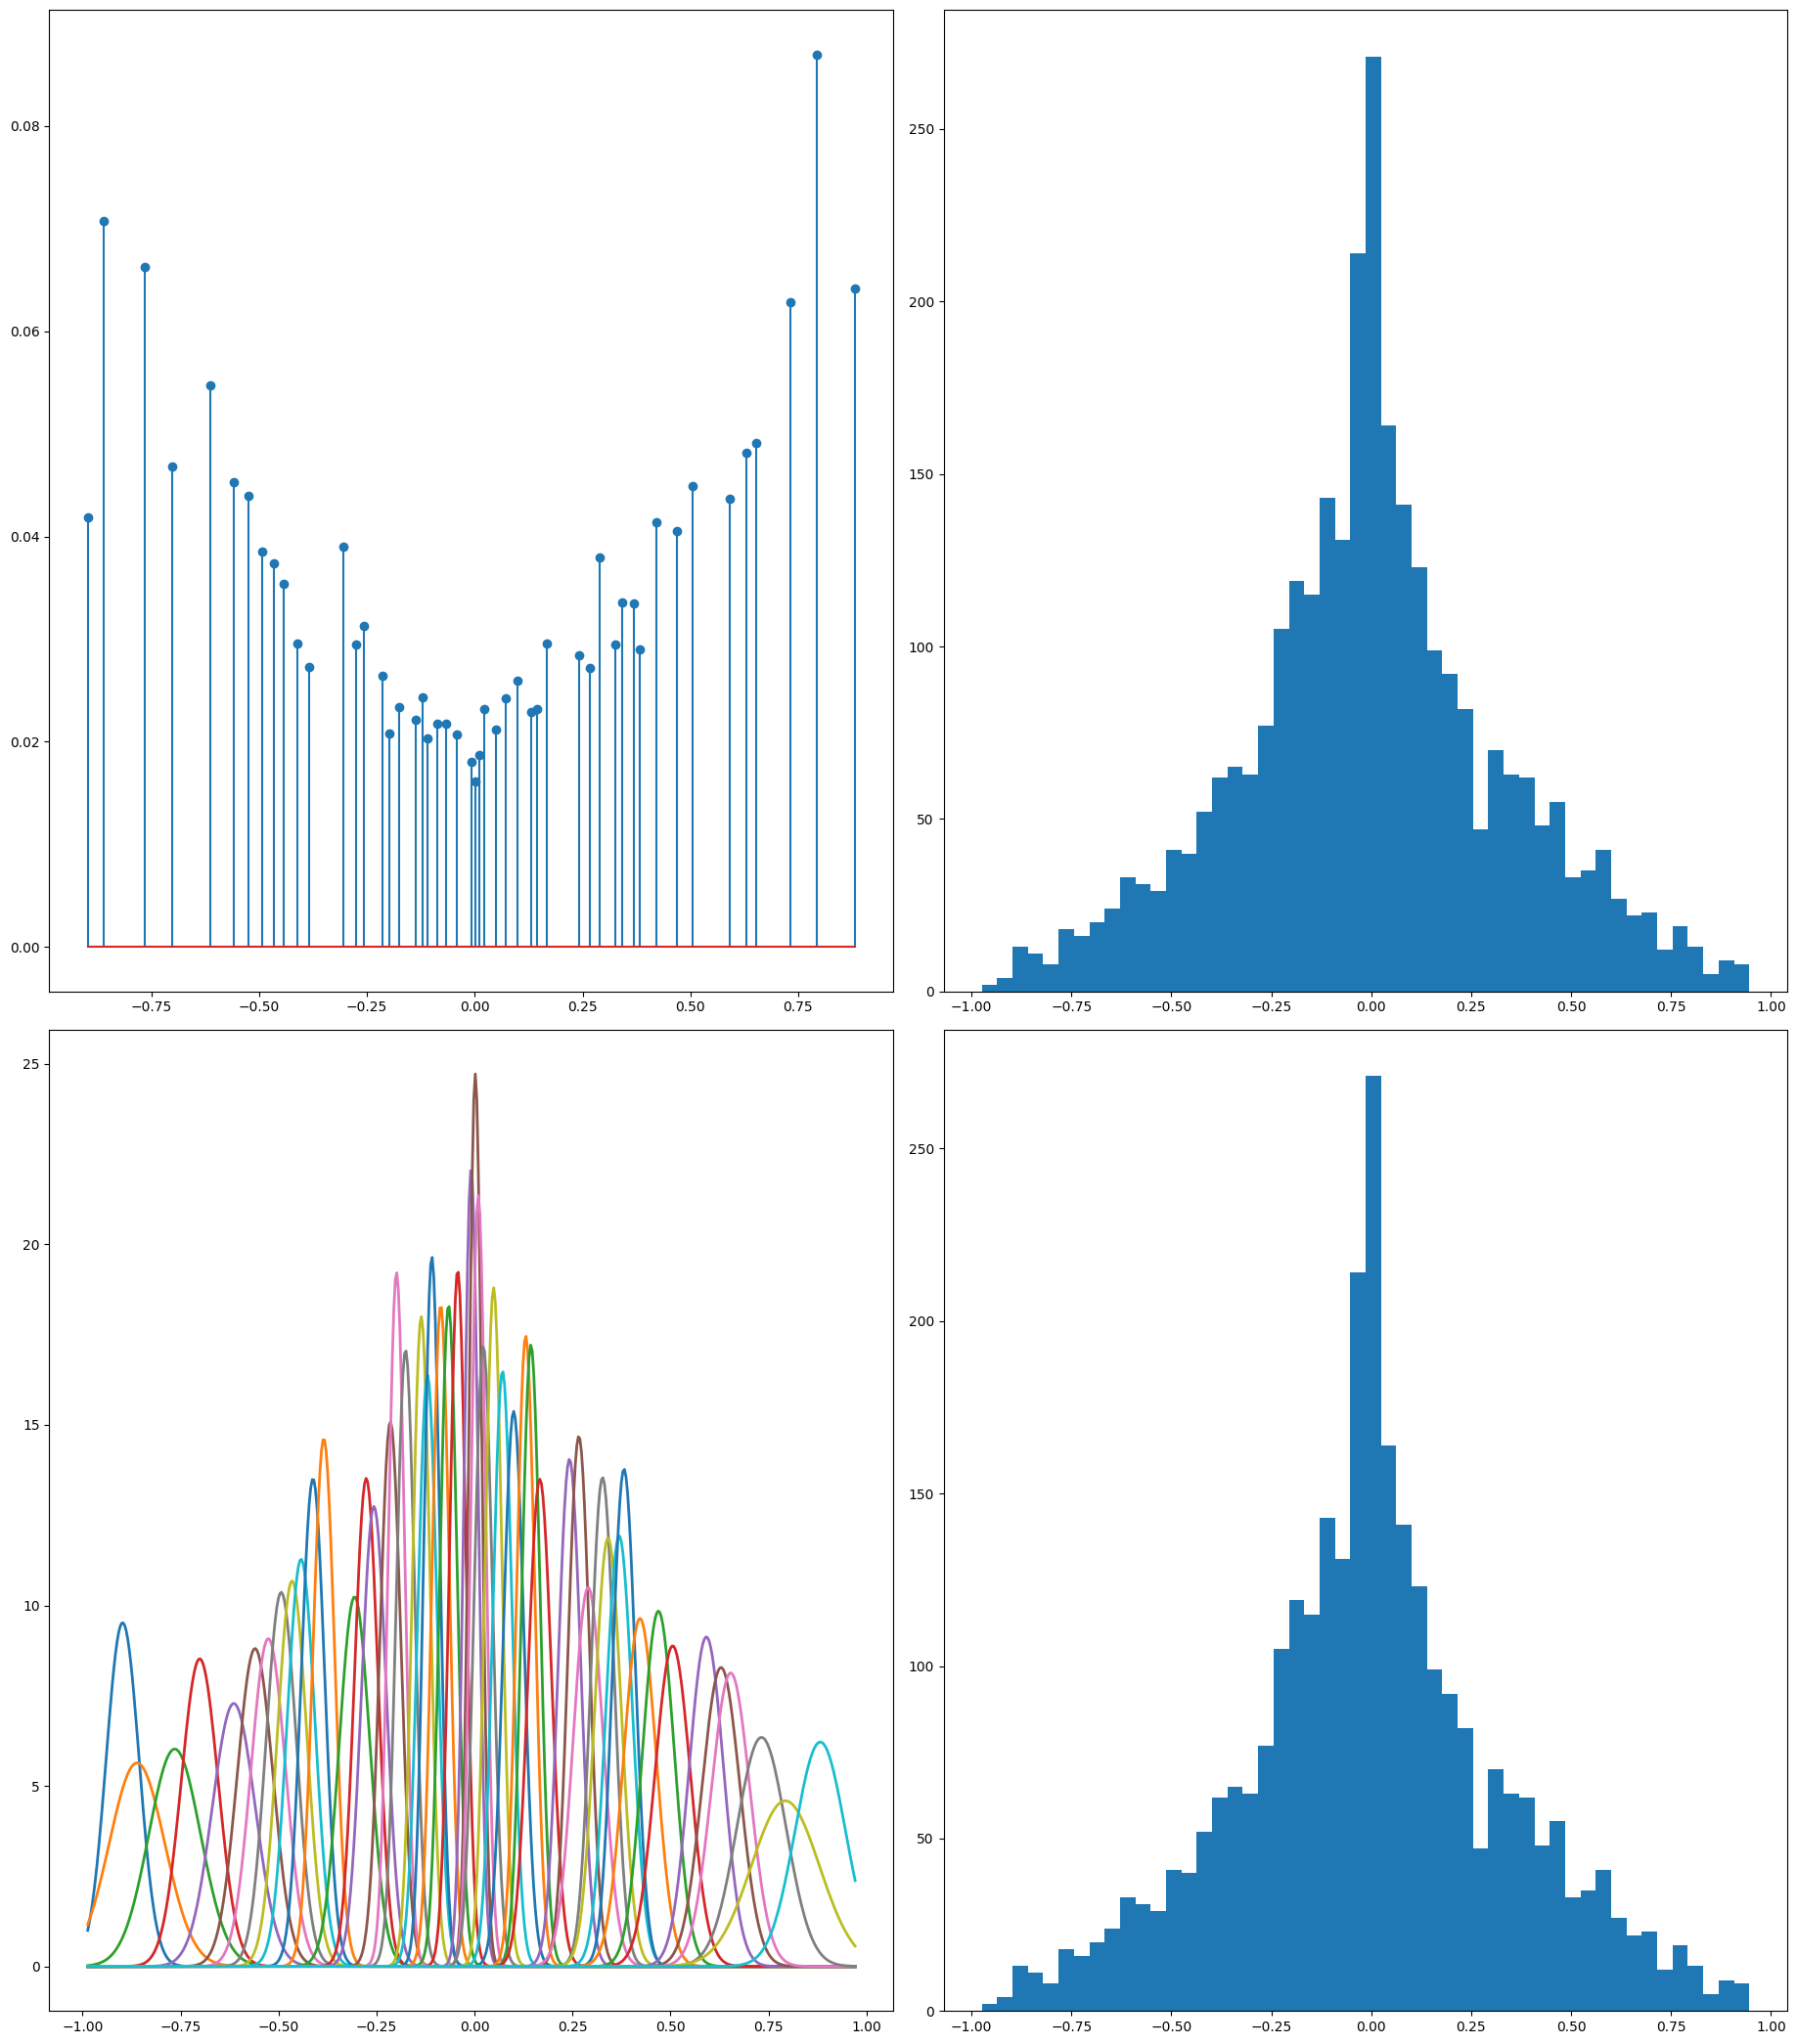

In [7]:

spn.plot_som_comparison_to_data(som_1, df['x_data'].tolist())
spn.plot_som_comparison_to_data(som_2, df['z_data'].tolist())
spn.plot_som_comparison_to_data(som_3, df['y_data'].tolist())

In [8]:
test_set = df.sample(1000)
test_set.sort_values(by=['y_data'])
errors = []
errors_distance = []
predicted_values = []

for _, row in test_set.iterrows():
    test_data = row
    result_test_value = test_data['y_data']
    predicted = spice_net.decode({'x_data': test_data['x_data'], 'z_data': test_data['z_data']},
                                 decoder='bert-optimizer')
    predicted_values.append(predicted)
    errors.append(abs(predicted - result_test_value) / 2 * 100)
    errors_distance.append(abs(predicted - result_test_value))
    print(f'Error: {errors[-1]:.6f},\t Predicted: {predicted:.6f},\t Actual: {result_test_value:.6f}')

print(f'Mean Error distance {np.mean(np.array(errors_distance))}')
print(f'Mean Error in % {np.mean(np.array(errors))}')
print(f'Median Error in % {np.median(np.array(errors))}')
print(f'Error std {np.std(np.array(errors))}')

Error: 2.799150,	 Predicted: -0.575782,	 Actual: -0.519799
Error: 4.875473,	 Predicted: 0.029566,	 Actual: 0.127076
Error: 11.002844,	 Predicted: 0.008246,	 Actual: -0.211811
Error: 27.020978,	 Predicted: 0.047118,	 Actual: -0.493302
Error: 3.008393,	 Predicted: 0.047118,	 Actual: -0.013050
Error: 7.520452,	 Predicted: 0.005235,	 Actual: 0.155644
Error: 25.954956,	 Predicted: -0.603947,	 Actual: -0.084848
Error: 3.693597,	 Predicted: 0.021868,	 Actual: 0.095739
Error: 1.777956,	 Predicted: -0.058313,	 Actual: -0.022754
Error: 0.713145,	 Predicted: 0.029908,	 Actual: 0.044171
Error: 5.826005,	 Predicted: 0.021900,	 Actual: -0.094620
Error: 9.681973,	 Predicted: -0.103063,	 Actual: 0.090577
Error: 25.486274,	 Predicted: 0.004696,	 Actual: 0.514422
Error: 1.274453,	 Predicted: 0.022376,	 Actual: -0.003113
Error: 37.794383,	 Predicted: 0.022215,	 Actual: 0.778103
Error: 20.259616,	 Predicted: -0.013978,	 Actual: -0.419171
Error: 17.197472,	 Predicted: -0.316752,	 Actual: 0.027197
Error: 7.

In [9]:
import plotly.express as px

direction = test_set['y_data'].to_numpy() - np.array(predicted_values)
error_df = pd.DataFrame(
    {'Index': range(1, len(errors) + 1),
     'Real': test_set['y_data'],
     'Distance': errors_distance,
     'dir': direction.tolist()})
fig = px.scatter(error_df, x="Index", y="Real", error_y="Distance")
fig.add_scatter(x=error_df['Index'].to_numpy(), y=predicted_values, fillcolor='orange', mode='markers',
                name='Predicted', zorder=1000)
#fig.add_scatter(x=error_df['Index'].to_numpy(), y=error_df['Real'].to_numpy(), fillcolor='green')
fig.show()